# Тестирование обученной модели

Загружает веса `GAPinn` (из артефактов ClearML-задачи или локально из
`trained_models/<run>/`), прогоняет их на тестовом сплите и визуализирует
результат: `phi` (pred vs gt по поверхностям), 3D векторное поле скорости `v`,
давление `p` (для `v`/`p` ground truth не существует в датасете — они не
супервайзятся напрямую, только через residual-лосс, поэтому здесь только pred).

Модель и `Dataset` продублированы из `main.py` (как и в `select_geometries.py`/
`augmentation_viz.ipynb` — импортировать `main.py` напрямую нельзя, он при
импорте запускает всё обучение). **Если архитектура `GAPinn` в `main.py`
изменится — синхронизируйте её здесь.**

In [1]:
import copy
import json
import os

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tqdm import tqdm

from modules import *

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {DEVICE}')

Using device: cuda


## Конфигурация

`TEST_STAGE`:
- `'phi'` — датасет как на 1-м этапе (все геометрии сплита, интерьер обрезан до
  первых 100k закэшированных точек). GT для `phi` корректен для всех типов точек.
- `'flow'` — вызывает `Dataset.enter_flow_stage()`: полный интерьер, но **только
  геометрии, принятые в `geometry_selection.json`** (см. `select_geometries.py`).
  ⚠️ у этого режима есть унаследованная из `main.py` особенность: при
  `phi_stage=False` GT для `phi_1` (`phi_w`) по **интерьеру** берётся как первые
  `INTERIOR_SIZE` закэшированных точек, а не по тем же случайным индексам, что и
  сами координаты `x` — т.е. для интерьера `phi_1` gt/pred сравнивать некорректно
  в этом режиме (стенки/вход/выход/outerior не затронуты).

In [96]:
# --- откуда брать датасет ---
LOCAL_DATASET = True
DATASET_PATH = 'SimVascDataset'          # если LOCAL_DATASET=True
CLEARML_DATASET_NAME = 'SimVascDatasetFull'
CLEARML_PROJECT = 'kornaeva-rnf/GA_PINN_3D'

# --- откуда брать веса модели ---
MODEL_SOURCE = 'clearml'                   # 'local' или 'clearml'

# MODEL_SOURCE == 'local'
LOCAL_RUN_DIR = 'trained_models/2026-01-01_00-00-00'   # папка конкретного прогона
CHECKPOINT_NAME = 'model_best.pth'                      # или 'model.pth'

# MODEL_SOURCE == 'clearml'
CLEARML_TASK_ID = '33d909feabcd4b0bbddd380548891492'                     # id задачи в ClearML

# --- сплит датасета, которым тестируем модель ---
TEST_SPLIT = 'train'                      # 'test' / 'val' / 'train'
TEST_STAGE = 'flow'                       # 'phi' или 'flow', см. markdown выше
FULL_TRAIN = False                        # должно совпадать с тем, чем обучалась модель

## Константы (как в `main.py`)

Должны совпадать с константами прогона, чьи веса тестируются — иначе размеры
тензоров/срезы `_BND_END` разъедутся с обученными весами.

In [104]:
USE_EMB = True
ACT = 'wave'

INTERIOR_SIZE = 500
WALLS_SIZE    = 250
INLET_SIZE    = 100
OUTLET_SIZE   = 100
OUTERIOR_SIZE = 250

Q = 1.5e-6
S = 2e-6

_BND_START = INTERIOR_SIZE
_BND_END   = INTERIOR_SIZE + WALLS_SIZE + INLET_SIZE + OUTLET_SIZE

GEN_POINTS = False

LABEL_NAMES = ['interior', 'walls', 'inlet', 'outlet', 'outerior']

In [91]:
not [True]

False

In [92]:
if not LOCAL_DATASET:
    from clearml import Dataset as ClearMLDataset
    _ds = ClearMLDataset.get(dataset_name=CLEARML_DATASET_NAME, dataset_project=CLEARML_PROJECT)
    DATASET_PATH = _ds.get_local_copy()

if FULL_TRAIN:
    with open('full_split.json', 'r') as fp:
        SPLIT = json.load(fp)    
else:
    with open('debug_split.json', 'r') as fp:
        SPLIT = json.load(fp) 

GEOMETRY_SELECTION_PATH = 'geometry_selection.json'
if os.path.exists(GEOMETRY_SELECTION_PATH):
    with open(GEOMETRY_SELECTION_PATH, 'r', encoding='utf-8') as fp:
        GEOMETRY_SELECTION = json.load(fp)
else:
    GEOMETRY_SELECTION = {}

ACCEPTED_GEOMETRIES = {k for k, v in GEOMETRY_SELECTION.items() if v == 'accept'}
print(f'{len(SPLIT[TEST_SPLIT])} case-директорий в сплите "{TEST_SPLIT}", '
      f'{len(ACCEPTED_GEOMETRIES)} принятых геометрий всего')

1 case-директорий в сплите "train", 122 принятых геометрий всего


In [93]:
class Dataset(torch.utils.data.Dataset):
    def __init__(self, path, split="train"):
        self.data = []
        self.keys = []
        for dir in os.listdir(path):
            if dir not in SPLIT[split]:
                continue
            for file in os.listdir(os.path.join(path, dir)):
                if (file.count('_') == 1) and (file.split('_')[-1] != '-1.stl') and ('.stl' in file):
                    if (GEN_POINTS) or (file.replace('.stl', '_interior.pt') in os.listdir(os.path.join(path, dir))):
                        self.data.append(load_stl(os.path.join(path, dir, file), odd=False, device='cuda', gen_p=GEN_POINTS))
                        self.keys.append(os.path.join(dir, file).replace("/", "\\"))
                        torch.cuda.empty_cache()

        self.phi_stage = True

    def enter_flow_stage(self):
        """Переход на 2-й этап (flow): оставляет только принятые в geometry_selection.json
        геометрии и выключает phi_stage. __len__ сам подхватывает укороченный self.data."""
        if not self.phi_stage:
            return

        keep = [i for i, k in enumerate(self.keys) if k in ACCEPTED_GEOMETRIES]
        if not keep:
            raise RuntimeError(
                f"Ни одна геометрия не помечена как 'accept' в {GEOMETRY_SELECTION_PATH} "
                "для этого сплита. Запустите select_geometries.py перед переходом на 2-й этап."
            )
        self.data = [self.data[i] for i in keep]
        self.keys = [self.keys[i] for i in keep]
        self.phi_stage = False

    def __getitem__(self, index):
        if index < len(self.data):
            inlet = 'inlet'
            outlet = 'outlet'
        else:
            index = index - len(self.data)
            inlet = 'outlet'
            outlet = 'inlet'

        agg = self.data[index]

        idx_int   = torch.randperm(len(agg['x_dict']['interior'][:(100000 if self.phi_stage else None)]))[:INTERIOR_SIZE]
        idx_w     = torch.randperm(len(agg['x_dict']['walls']))[:WALLS_SIZE]
        idx_in    = torch.randperm(len(agg['x_dict'][inlet]))[:INLET_SIZE]
        idx_out   = torch.randperm(len(agg['x_dict'][outlet]))[:OUTLET_SIZE]
        idx_outer = torch.randperm(len(agg['x_dict']['outerior']))[:OUTERIOR_SIZE]

        x = torch.cat([
            agg['x_dict']['interior'][idx_int],
            agg['x_dict']['walls'][idx_w],
            agg['x_dict'][inlet][idx_in],
            agg['x_dict'][outlet][idx_out],
            agg['x_dict']['outerior'][idx_outer],
        ], dim=0)

        # 0=interior, 1=walls, 2=inlet, 3=outlet, 4=outerior
        x_label = torch.cat([
            torch.zeros(INTERIOR_SIZE,             dtype=torch.long),
            torch.ones(WALLS_SIZE,                 dtype=torch.long),
            torch.full((INLET_SIZE,),    2,        dtype=torch.long),
            torch.full((OUTLET_SIZE,),   3,        dtype=torch.long),
            torch.full((OUTERIOR_SIZE,), 4,        dtype=torch.long),
        ])

        phi_w = torch.cat([
            agg['phi_w_dict']['interior'][idx_int] if self.phi_stage else agg['phi_w_dict']['interior'][:INTERIOR_SIZE],
            agg['phi_w_dict']['walls'][idx_w],
            agg['phi_w_dict'][inlet][idx_in],
            agg['phi_w_dict'][outlet][idx_out],
            agg['phi_w_dict']['outerior'][idx_outer],
        ])

        phi_key = "in" if inlet == 'inlet' else 'out'

        phi_in = torch.cat([
                agg[f'phi_{phi_key}_dict']['interior'][idx_int] if self.phi_stage else agg[f'phi_{phi_key}_dict']['interior'][:INTERIOR_SIZE],
                agg[f'phi_{phi_key}_dict']['walls'][idx_w],
                agg[f'phi_{phi_key}_dict']['inlet'][idx_in],
                agg[f'phi_{phi_key}_dict']['outlet'][idx_out],
                agg[f'phi_{phi_key}_dict']['outerior'][idx_outer],
            ])

        norm_in    = agg['n_dict'][inlet]
        norm_out   = agg['n_dict'][outlet]
        center_in = agg['n_dict'][f'{inlet}_center']
        center_out = agg['n_dict'][f'{outlet}_center']

        l = agg['l']
        if inlet  == 'inlet':
            s = agg['s_in']
            v_mean = agg['v_mean_in']
        else:
            s = agg['s_out']
            v_mean = agg['v_mean_out']

        return x, torch.stack((phi_w, phi_in), 1), torch.cat((center_in, center_out)), norm_in.repeat(len(x), 1), norm_out.repeat(len(x), 1), center_out.repeat(len(x), 1), l.repeat(len(x), 1), s.repeat(len(x), 1), v_mean.repeat(len(x), 1), x_label

    def __len__(self):
        return len(self.data) * 2

In [94]:
def get_clones(module, N):
    return nn.ModuleList([copy.deepcopy(module) for i in range(N)])

def get_act():
    if ACT == 'wave':
        return WaveAct()
    elif ACT == 'tanh':
        return torch.nn.Tanh()
    elif ACT == 'silu':
        return nn.SiLU(inplace=True)

class WaveAct(nn.Module):
    def __init__(self):
        super(WaveAct, self).__init__()
        self.w1 = nn.Parameter(torch.ones(1), requires_grad=True)
        self.w2 = nn.Parameter(torch.ones(1), requires_grad=True)

    def forward(self, x):
        return self.w1 * torch.sin(x) + self.w2 * torch.cos(x)

class FeedForward(nn.Module):
    def __init__(self, d_model, d_ff=256):
        super(FeedForward, self).__init__()
        self.linear = nn.Sequential(*[
            nn.Linear(d_model, d_ff),
            get_act(),
            nn.Linear(d_ff, d_ff),
            get_act(),
            nn.Linear(d_ff, d_model)
        ])

    def forward(self, x):
        return self.linear(x)


class EncoderLayer(nn.Module):
    def __init__(self, d_model, heads):
        super(EncoderLayer, self).__init__()

        self.attn = nn.MultiheadAttention(embed_dim=d_model, num_heads=heads, batch_first=True)
        self.ff = FeedForward(d_model)
        self.act1 = get_act()
        self.act2 = get_act()

    def forward(self, x):
        x2 = self.act1(x)
        x = x + self.attn(x2,x2,x2)[0]
        x2 = self.act2(x)
        x = x + self.ff(x2)
        return x


class DecoderLayer(nn.Module):
    def __init__(self, d_model, heads):
        super(DecoderLayer, self).__init__()

        self.attn = nn.MultiheadAttention(embed_dim=d_model, num_heads=heads, batch_first=True)
        self.ff = FeedForward(d_model)
        self.act1 = get_act()
        self.act2 = get_act()

    def forward(self, x, e_outputs):
        x2 = self.act1(x)
        x = x + self.attn(x2, e_outputs, e_outputs)[0]
        x2 = self.act2(x)
        x = x + self.ff(x2)
        return x


class Encoder(nn.Module):
    def __init__(self, d_model, N, heads):
        super(Encoder, self).__init__()
        self.N = N
        self.layers = get_clones(EncoderLayer(d_model, heads), N)
        self.act = get_act()

    def forward(self, x):
        for i in range(self.N):
            x = self.layers[i](x)
        return self.act(x)


class Decoder(nn.Module):
    def __init__(self, d_model, N, heads):
        super(Decoder, self).__init__()
        self.N = N
        self.layers = get_clones(DecoderLayer(d_model, heads), N)
        self.act = get_act()

    def forward(self, x, e_outputs):
        for i in range(self.N):
            x = self.layers[i](x, e_outputs)
        return self.act(x)


class GAPinn(nn.Module):
    def __init__(self, d_hidden=512, d_model=256, N=4, heads=8):
        super(GAPinn, self).__init__()

        if USE_EMB:
            self.embedding = nn.Embedding(5, d_model)

        self.linear_emb = nn.Linear(9, d_model)

        self.encoder = Encoder(d_model, N, heads)
        self.decoder_phi = Decoder(d_model, N, heads)

        self.linear_out_phi = nn.Sequential(*[
            nn.Linear(d_model, d_hidden),
            get_act(),
            nn.Linear(d_hidden, d_hidden),
            get_act(),
            nn.Linear(d_hidden, 2)
        ])

        self.linear_out_v = nn.Sequential(*[
            nn.Linear(d_model, d_hidden),
            get_act(),
            nn.Linear(d_hidden, d_hidden),
            get_act(),
            nn.Linear(d_hidden, d_hidden),
            get_act(),
            nn.Linear(d_hidden, d_hidden),
            get_act(),
            nn.Linear(d_hidden, d_hidden),
            get_act(),
            nn.Linear(d_hidden, d_hidden),
            get_act(),
            nn.Linear(d_hidden, d_hidden),
            get_act(),
            nn.Linear(d_hidden, d_hidden),
            get_act(),
            nn.Linear(d_hidden, d_hidden),
            get_act(),
            nn.Linear(d_hidden, d_hidden),
            get_act(),
            nn.Linear(d_hidden, 3)
        ])

        self.linear_out_p = nn.Sequential(*[
            nn.Linear(d_model, d_hidden),
            get_act(),
            nn.Linear(d_hidden, d_hidden),
            get_act(),
            nn.Linear(d_hidden, 1)
        ])

    def forward(self, x, out, norm_in, norm_out, center_out, l, s, v_mean, x_label, pinn=False):
        if pinn:
            x_grad = x * 2 * l
            x_grad.requires_grad_(True)
            x_proj_enc = self.linear_emb(torch.cat((x_grad.clone().detach() / l / 2, out.unsqueeze(1).repeat(1, x.shape[1], 1)), -1))
            if USE_EMB:
                label_emb = self.embedding(x_label)
                x_proj_enc = x_proj_enc + label_emb
            x_proj_dec = self.linear_emb(torch.cat((x_grad / l / 2, out.unsqueeze(1).repeat(1, x.shape[1], 1)), -1))
        else:
            x_grad = None
            x_proj_enc = x_proj_dec = self.linear_emb(torch.cat((x, out.unsqueeze(1).repeat(1, x.shape[1], 1)), -1))
            if USE_EMB:
                label_emb = self.embedding(x_label)
                x_proj_enc = x_proj_enc + label_emb

        e_outputs = self.encoder(x_proj_enc)

        d_output_phi = self.decoder_phi(x_proj_dec, e_outputs)
        d_output_flow = self.decoder_phi(x_proj_dec[:, :_BND_END], e_outputs[:, :_BND_END])

        phi_pred = self.linear_out_phi(d_output_phi)
        v = self.linear_out_v(d_output_flow)
        p = self.linear_out_p(d_output_flow)

        v = (v * phi_pred[:, :_BND_END, 1:2]
                  + phi_pred[:, :_BND_END, 0:1] * norm_in[:, :_BND_END] * ((1 / v_mean[:, :_BND_END])*((Q * (s[:, :_BND_END] / S)) / s[:, :_BND_END])))

        signed_dist = ((x[:, :_BND_END] - center_out[:, :_BND_END])
                       * norm_out[:, :_BND_END]).sum(-1, keepdim=True)
        p = p * signed_dist * 10

        return None, phi_pred, v[..., 0:1], v[..., 1:2], v[..., 2:3], p, x_grad

## Загрузка модели

In [81]:
ga_pinn = GAPinn().to(DEVICE)

if MODEL_SOURCE == 'clearml':
    from clearml import Task
    resume_task = Task.get_task(task_id=CLEARML_TASK_ID, project_name=CLEARML_PROJECT)
    model_path = resume_task.artifacts['model'].get_local_copy()
elif MODEL_SOURCE == 'local':
    model_path = os.path.join(LOCAL_RUN_DIR, CHECKPOINT_NAME)
else:
    raise ValueError(f'Unknown MODEL_SOURCE: {MODEL_SOURCE!r}')

ga_pinn.load_state_dict(torch.load(model_path, map_location=DEVICE))
ga_pinn.eval()
print(f'Loaded weights from: {model_path}')

Loaded weights from: F:/storage_manager/global/ede9224bba5d07eca4a209ac5828acff.model.pth


In [97]:
dataset_test = Dataset(DATASET_PATH, TEST_SPLIT)
if TEST_STAGE == 'flow':
    dataset_test.enter_flow_stage()

print(f'{len(dataset_test)} тестовых сэмплов ({len(dataset_test.data)} геометрий x2), '
      f'phi_stage={dataset_test.phi_stage}')

Outerior points generation with path: SimVascDataset\0145_H_CORO_KD\1_1.stl
done

Interior points generation
done

Inlet points generation
done

Outlet points generation
done

Walls points generation
done


Outerior points generation with path: SimVascDataset\0145_H_CORO_KD\1_2.stl
done

Interior points generation
done

Inlet points generation
done

Outlet points generation
done

Walls points generation
done


Outerior points generation with path: SimVascDataset\0145_H_CORO_KD\1_3.stl
done

Interior points generation
done

Inlet points generation
done

Outlet points generation
done

Walls points generation
done


Outerior points generation with path: SimVascDataset\0145_H_CORO_KD\1_4.stl
done

Interior points generation
done

Inlet points generation
done

Outlet points generation
done

Walls points generation
done


Outerior points generation with path: SimVascDataset\0145_H_CORO_KD\1_5.stl
done

Interior points generation
done

Inlet points generation
done

Outlet points generation
do

## Инференс на одном образце

In [98]:
def set_axes_equal(ax):
    """mplot3d не выравнивает оси по умолчанию — без этого форма визуально искажается."""
    limits = np.array([ax.get_xlim3d(), ax.get_ylim3d(), ax.get_zlim3d()])
    centers = limits.mean(axis=1)
    radius = 0.5 * max(limits[:, 1] - limits[:, 0])
    ax.set_xlim3d([centers[0] - radius, centers[0] + radius])
    ax.set_ylim3d([centers[1] - radius, centers[1] + radius])
    ax.set_zlim3d([centers[2] - radius, centers[2] + radius])


def run_inference(dataset, idx):
    """Прогоняет один сэмпл датасета через модель (без градиентов, pinn=False —
    для визуализации forward-предсказаний производные по x не нужны)."""
    subset = torch.utils.data.Subset(dataset, [idx])
    loader = torch.utils.data.DataLoader(subset, batch_size=1)
    x, phi, out, norm_in, norm_out, center_out, l, s, v_mean, x_label = next(iter(loader))
    x, phi, out, norm_in, norm_out, center_out, l, s, v_mean, x_label = \
        x.to(DEVICE), phi.to(DEVICE), out.to(DEVICE), norm_in.to(DEVICE), norm_out.to(DEVICE), \
        center_out.to(DEVICE), l.to(DEVICE), s.to(DEVICE), v_mean.to(DEVICE), x_label.to(DEVICE)

    with torch.no_grad():
        _, phi_pred, v1, v2, v3, p, _ = ga_pinn(x, out, norm_in, norm_out, center_out, l, s, v_mean, x_label, pinn=False)

    return dict(x=x[0], phi=phi[0], phi_pred=phi_pred[0], x_label=x_label[0],
                v1=v1[0, :, 0], v2=v2[0, :, 0], v3=v3[0, :, 0], p=p[0, :, 0])


IDX = 0  # индекс тестового сэмпла — поменяйте, чтобы посмотреть другую геометрию
result = run_inference(dataset_test, IDX)
print({k: tuple(v.shape) for k, v in result.items()})

{'x': (12000, 3), 'phi': (12000, 2), 'phi_pred': (12000, 2), 'x_label': (12000,), 'v1': (9500,), 'v2': (9500,), 'v3': (9500,), 'p': (9500,)}


## Phi: pred vs gt по поверхностям

Канал 0 = phi_1 (расстояние до стенок), канал 1 = phi_2 (расстояние до стенок и входа).

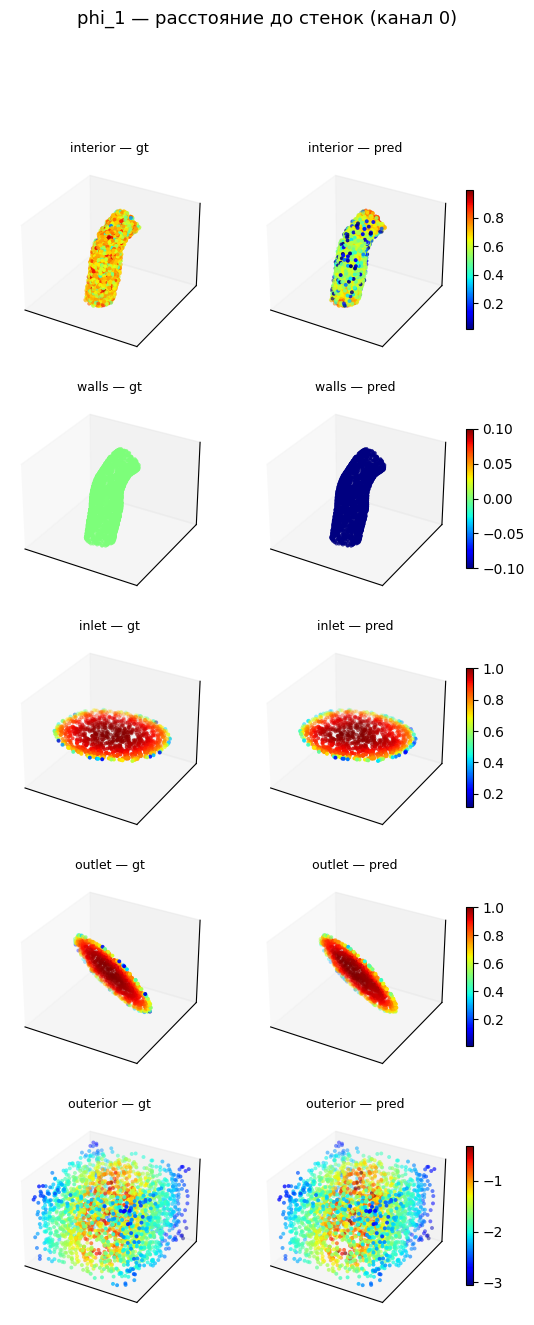

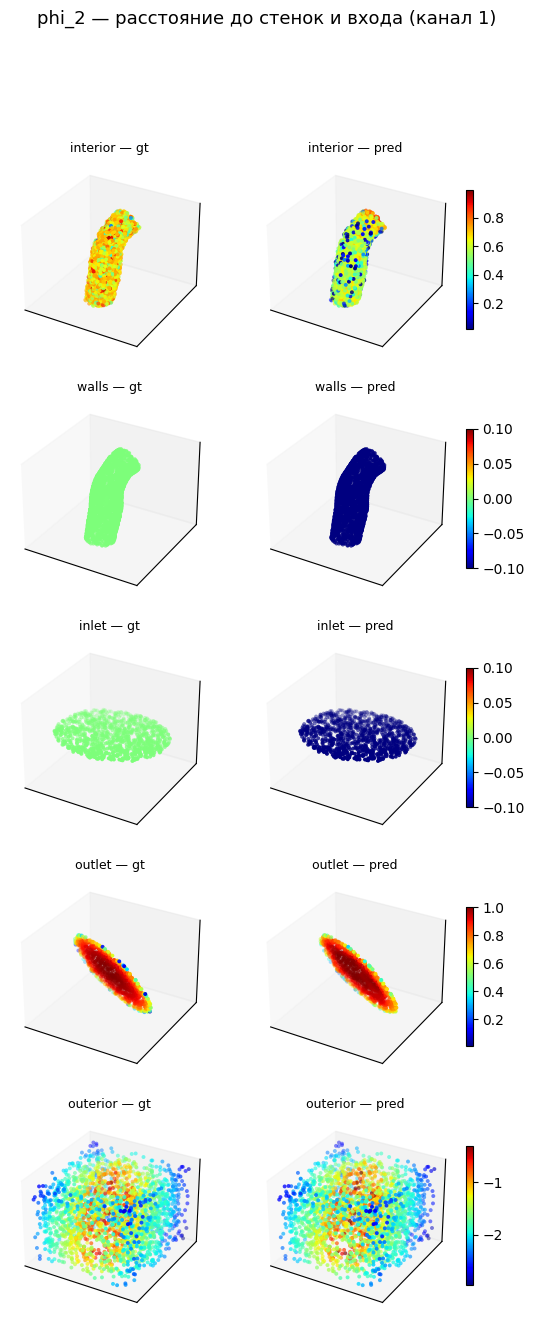

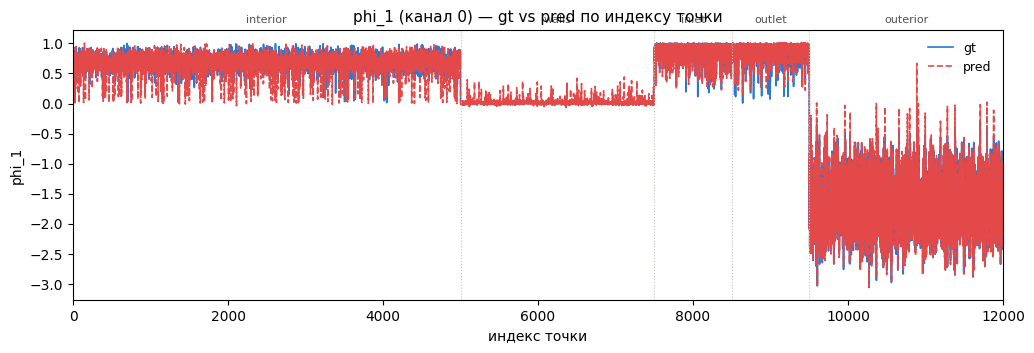

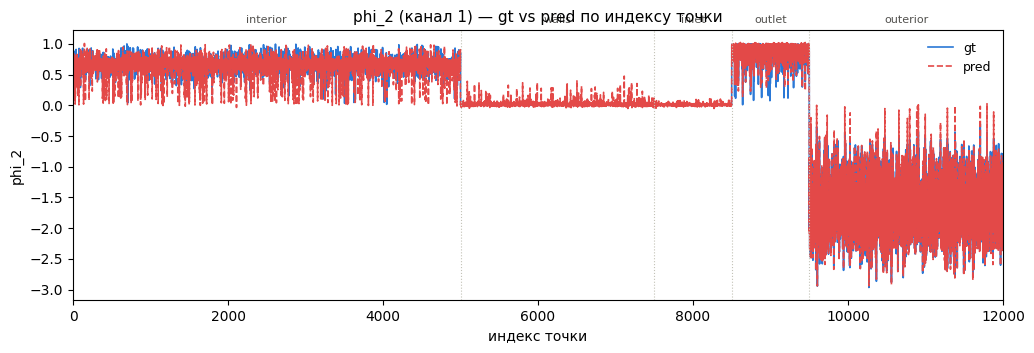

In [99]:
def scatter_scalar(ax, points, values, title, vmin=None, vmax=None):
    points = points.detach().cpu().numpy()
    values = values.detach().cpu().numpy()
    sc = ax.scatter(points[:, 0], points[:, 1], points[:, 2], c=values, cmap='jet',
                     s=8, vmin=vmin, vmax=vmax, linewidths=0)
    ax.set_title(title, fontsize=9)
    ax.set_xticks([]); ax.set_yticks([]); ax.set_zticks([])
    set_axes_equal(ax)
    return sc


def plot_phi_channel(result, channel, channel_name):
    x = result['x']
    label = result['x_label']
    gt = result['phi'][:, channel]
    pred = result['phi_pred'][:, channel]

    vmin = float(min(gt.min(), pred.min()))
    vmax = float(max(gt.max(), pred.max()))

    fig, axes = plt.subplots(len(LABEL_NAMES), 2, figsize=(7, 3 * len(LABEL_NAMES)),
                              subplot_kw={'projection': '3d'})
    for row, name in enumerate(LABEL_NAMES):
        mask = label == row
        sc = scatter_scalar(axes[row, 0], x[mask], gt[mask], f'{name} — gt', gt[mask].min(), gt[mask].max())
        scatter_scalar(axes[row, 1], x[mask], pred[mask], f'{name} — pred', gt[mask].min(), gt[mask].max())
        fig.colorbar(sc, ax=axes[row, :], shrink=0.7, pad=0.02)

    fig.suptitle(f'{channel_name} (канал {channel})', fontsize=13)
    plt.show()


# gt vs pred по индексу точки — дополняет 3D scatter выше числовым сравнением
# (проще увидеть величину ошибки, чем по цвету на облаке точек).
def plot_phi_curve(result, channel, channel_name):
    label = result['x_label'].cpu().numpy()
    gt = result['phi'][:, channel].detach().cpu().numpy()
    pred = result['phi_pred'][:, channel].detach().cpu().numpy()

    counts = np.bincount(label, minlength=len(LABEL_NAMES))
    boundaries = np.cumsum(counts)

    fig, ax = plt.subplots(figsize=(12, 3.5))
    ax.plot(gt, label='gt', color='#2a78d6', linewidth=1.2)
    ax.plot(pred, label='pred', color='#e34948', linewidth=1.2, linestyle='--')

    prev = 0
    for name, boundary, count in zip(LABEL_NAMES, boundaries, counts):
        if count == 0:
            continue
        if prev > 0:
            ax.axvline(prev, color='#c3c2b7', linewidth=0.8, linestyle=':')
        ax.text(prev + count / 2, 1.02, name, transform=ax.get_xaxis_transform(),
                ha='center', va='bottom', fontsize=8, color='#52514e')
        prev = boundary

    ax.set_xlim(0, len(label))
    ax.set_xlabel('индекс точки')
    ax.set_ylabel(channel_name)
    ax.legend(frameon=False, fontsize=9, loc='upper right')
    ax.set_title(f'{channel_name} (канал {channel}) — gt vs pred по индексу точки', fontsize=11)
    plt.show()


plot_phi_channel(result, 0, 'phi_1 — расстояние до стенок')
plot_phi_channel(result, 1, 'phi_2 — расстояние до стенок и входа')

plot_phi_curve(result, 0, 'phi_1')
plot_phi_curve(result, 1, 'phi_2')

## Скорость v: 3D векторное поле и по поверхностям

GT для скорости в датасете нет (супервизия только через residual-лосс на
flow-этапе), поэтому здесь только предсказание. `v` считается только для
`interior/walls/inlet/outlet` (`_BND_END` в `main.py`), для `outerior` — нет.

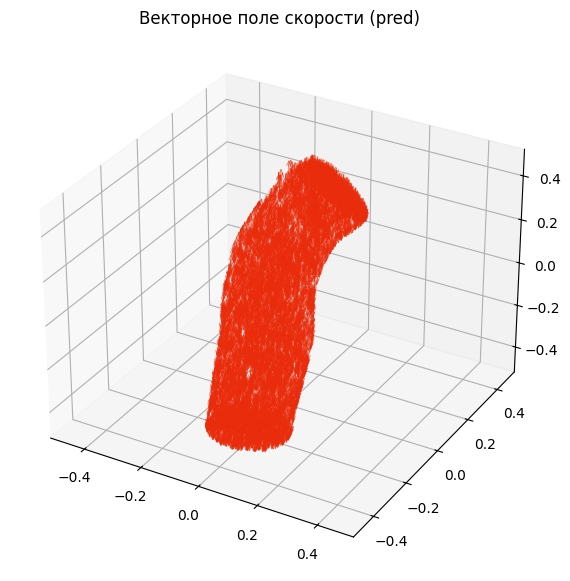

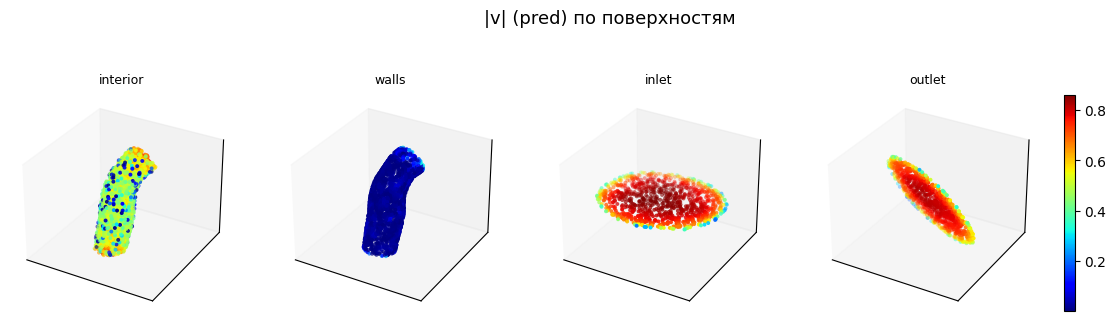

In [103]:
def plot_velocity_field(result, step=1):
    x = result['x'][:_BND_END].detach().cpu().numpy()
    u = result['v1'].detach().cpu().numpy()
    v = result['v2'].detach().cpu().numpy()
    w = result['v3'].detach().cpu().numpy()
    speed = np.sqrt(u ** 2 + v ** 2 + w ** 2)

    fig = plt.figure(figsize=(7, 7))
    ax = fig.add_subplot(projection='3d')
    scale = float(np.abs(x).max()) * 0.08

    # Направление — сплошным цветом через quiver (mplot3d.quiver не умеет надёжно
    # красить каждую стрелку по массиву — количество сегментов линии не совпадает
    # с числом стрелок из-за наконечников). Модуль скорости — отдельно через scatter.
    ax.quiver(x[::step, 0], x[::step, 1], x[::step, 2],
              u[::step], v[::step], w[::step],
              length=scale, normalize=True, color="#e92c0b",
              linewidth=0.6, arrow_length_ratio=0.6, alpha=0.6)
    # sc = ax.scatter(x[::step, 0], x[::step, 1], x[::step, 2], c=speed[::step],
                    #  cmap='Blues', s=10, linewidths=0)

    # fig.colorbar(sc, ax=ax, shrink=0.7, label='|v|')
    ax.set_title('Векторное поле скорости (pred)')
    set_axes_equal(ax)
    plt.show()


def plot_scalar_by_surface(result, values, title, surfaces=('interior', 'walls', 'inlet', 'outlet')):
    x = result['x'][:_BND_END]
    label = result['x_label'][:_BND_END]
    vmin, vmax = float(values.min()), float(values.max())

    fig, axes = plt.subplots(1, len(surfaces), figsize=(4 * len(surfaces), 4),
                              subplot_kw={'projection': '3d'})
    for ax, name in zip(np.atleast_1d(axes), surfaces):
        row = LABEL_NAMES.index(name)
        mask = label == row
        sc = scatter_scalar(ax, x[mask], values[mask], name, vmin, vmax)
    fig.colorbar(sc, ax=axes, shrink=0.7, pad=0.02)
    fig.suptitle(title, fontsize=13)
    plt.show()


plot_velocity_field(result)

speed = (result['v1'] ** 2 + result['v2'] ** 2 + result['v3'] ** 2) ** 0.5
plot_scalar_by_surface(result, speed, '|v| (pred) по поверхностям')

## Давление p по поверхностям

Аналогично `v` — GT нет, только pred. Абсолютное значение не имеет физического
смысла (в residual-лоссе участвует только градиент давления), важна форма поля.

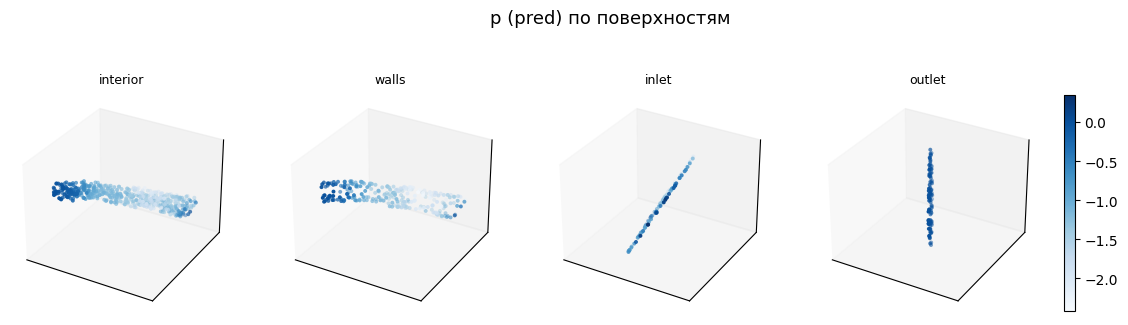

In [58]:
plot_scalar_by_surface(result, result['p'], 'p (pred) по поверхностям')

## Тест по всей тестовой выборке

Количественно можно оценить только `phi` (единственное поле с GT). Прогоняет
весь `dataset_test`, усредняет MAE по обоим каналам phi.

In [101]:
mae_phi1, mae_phi2 = [], []

for idx in tqdm(range(len(dataset_test))):
    r = run_inference(dataset_test, idx)
    err = (r['phi_pred'] - r['phi']).abs().mean(dim=0)
    mae_phi1.append(err[0].item())
    mae_phi2.append(err[1].item())

print(f'phi_1 MAE: {np.mean(mae_phi1):.4f} ± {np.std(mae_phi1):.4f}  (по {len(mae_phi1)} сэмплам)')
print(f'phi_2 MAE: {np.mean(mae_phi2):.4f} ± {np.std(mae_phi2):.4f}')

100%|██████████| 4/4 [00:05<00:00,  1.31s/it]

phi_1 MAE: 0.0703 ± 0.0016  (по 4 сэмплам)
phi_2 MAE: 0.0663 ± 0.0033
